<a href="https://colab.research.google.com/github/tagakj/CL_2025_PROJECT_2/blob/main/project2_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))
from collections import Counter
from nltk import ngrams

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
!pip install pymystem3

In [ ]:
from pymystem3 import Mystem

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.metrics import classification_report, r2_score, mean_absolute_error, mean_squared_error

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc

In [ ]:
qa_df = pd.read_excel("qa_table.xlsx", index_col=0)
qa_df

,category,date,question_theme,question_text
0,Гинекология,20.12.2025,Как прервать беременность в домашних условиях?,\n Как прервать беременност...
1,ЭКО,08.12.2025,"Обязательно ли иметь здоровых детей, чтобы ста...",\n Во многих клиниках обяза...
2,ЭКО,05.12.2025,"Может ли женщина быть донором, если у нее кариес?",\n Если у девушки проблемы...
3,Другое,05.12.2025,Может ли проконсультировать Ругайбат Е.Д. в пе...,"\n Здравствуйте, скажите по..."
4,Другое,05.12.2025,Можно ли сделать МСКТ с контрастированием брюш...,\n Добрый день. Можно ли сд...
...,...,...,...,...
4925,Другое,23.10.2014,"Лечение запоров у ребенка 4,5 месяцев: советы ...",\n Здравствуйте !!!Моему сы...
4926,Другое,23.10.2014,У ребенка 4 месяцев частый стул после кормлени...,"\n Ребенку 4 месяца, послед..."
4927,Другое,23.10.2014,Оптимальная схема прикорма для ребенка 6 месяцев,\n Ребенку 6 месяцев. На гр...
4928,Другое,23.10.2014,Лечение вульвовагинита при грудном вскармливан...,\n Здравствуйте! Очень наде...


In [ ]:
category_counts = qa_df['category'].value_counts()
print(category_counts)

category
Другое                 2947
Беременность и роды     676
Гинекология             524
ЭКО                     320
Педиатрия               188
Хирургия                117
Терапия                  87
Онкология                27
Стоматология             24
Name: count, dtype: int64


In [ ]:
# убираем пустые, другие, терапия, онкология, стоматология
qa_df_short = qa_df.loc[~((qa_df['category'] == 'Другое')| (qa_df['category'].isna())| (qa_df['category'] == 'Хирургия')| (qa_df['category'] == 'Терапия')| (qa_df['category'] == 'Онкология')| (qa_df['category'] == 'Стоматология'))].copy()
qa_df_short

,category,date,question_theme,question_text
0,Гинекология,20.12.2025,Как прервать беременность в домашних условиях?,\n Как прервать беременност...
1,ЭКО,08.12.2025,"Обязательно ли иметь здоровых детей, чтобы ста...",\n Во многих клиниках обяза...
2,ЭКО,05.12.2025,"Может ли женщина быть донором, если у нее кариес?",\n Если у девушки проблемы...
5,Гинекология,04.12.2025,Можно ли обследовать девочку у гинеколога?,\n Здравствуйте! Возможно п...
6,Беременность и роды,04.12.2025,Как выносить и родить здорового малыша с резус...,\n Здравствуйте. У меня кро...
...,...,...,...,...
3993,Беременность и роды,23.10.2014,Беременность при фиброзно-кистозной мастопатии...,"\n , Мне 26 лет, я пока тол..."
4641,Педиатрия,23.10.2014,Шансы исчезновения телеангиоэктазий у ребенка ...,\n Здравствуйте! У моего м...
4660,Педиатрия,23.10.2014,Нормальная температура и прикорм для ребенка 5...,\n Добрый день. У меня к ва...
4664,Педиатрия,23.10.2014,Почему ребенок в 2 месяца постоянно тужится: п...,\n Мой ребенок постоянно ту...


In [ ]:
category_counts = qa_df_short['category'].value_counts()
print(category_counts)

category
Беременность и роды    676
Гинекология            524
ЭКО                    320
Педиатрия              188
Name: count, dtype: int64


In [ ]:
# предварительно очищаем текст, готовим тексты к лемматизации
texts_for_lemm = qa_df_short['question_text'].tolist()
texts_for_lemm = [re.sub(r'\s+', ' ', text).strip() for text in texts_for_lemm]
pattern = r'(добрый день|день добрый)[^\w\s]*\s*'
texts_for_lemm = [re.sub(pattern, '', text, flags=re.IGNORECASE) for text in texts_for_lemm]
print(len(texts_for_lemm))
texts_for_lemm[:5]

1708


['Как прервать беременность в домашних условиях 9 недель',
 'Во многих клиниках обязательным требованием для становления донором яйцеклеток является наличие здоровых детей. У вас я данного пункта не нашла, поэтому хочу спросить, имеет ли значение отсутствие детей?',
 'Если у девушки проблемы с зубами ( кариес ) Может ли она стать донором ? У нее есть один здоровый ребенок',
 'Здравствуйте! Возможно пройти обследование девочки (18 лет 07.02.2008 исполнится) у гинеколога. (Жалобы на выделения. Киста (?) Спасибо.',
 'Здравствуйте. У меня кровь 2- у мужа 1+. Первая беременность 2011 г. ребёнок умер, было центральное предлежание плаценты, отслойка в 30 недель. Ребенок резус +, иммуноглобулин не кололи. 2014 г. титры вылезли на 20 неделе, ребёнок родился, была затяжная желтуха. 2020 г. титры вылезли уже в 12 недель, ребенку делали заменное переливание после рождения. 2025 г. антитела вылезли в 9 недель Титры к 20 недели были уже 1:64 и больше не росли. В 31 недели у ребенка по УЗИ обнаружили

In [ ]:
# заменяем колонку с текстом вопросов на очищенные тексты, готовые к лемматизации
qa_df_short.loc[:, 'question_text'] = texts_for_lemm
qa_df_short

,category,date,question_theme,question_text
0,Гинекология,20.12.2025,Как прервать беременность в домашних условиях?,Как прервать беременность в домашних условиях ...
1,ЭКО,08.12.2025,"Обязательно ли иметь здоровых детей, чтобы ста...",Во многих клиниках обязательным требованием дл...
2,ЭКО,05.12.2025,"Может ли женщина быть донором, если у нее кариес?",Если у девушки проблемы с зубами ( кариес ) Мо...
5,Гинекология,04.12.2025,Можно ли обследовать девочку у гинеколога?,Здравствуйте! Возможно пройти обследование дев...
6,Беременность и роды,04.12.2025,Как выносить и родить здорового малыша с резус...,Здравствуйте. У меня кровь 2- у мужа 1+. Перва...
...,...,...,...,...
3993,Беременность и роды,23.10.2014,Беременность при фиброзно-кистозной мастопатии...,", Мне 26 лет, я пока только планирую беременно..."
4641,Педиатрия,23.10.2014,Шансы исчезновения телеангиоэктазий у ребенка ...,Здравствуйте! У моего малыша с рождения красны...
4660,Педиатрия,23.10.2014,Нормальная температура и прикорм для ребенка 5...,"У меня к вам несколько вопросов, ия буду ВАм о..."
4664,Педиатрия,23.10.2014,Почему ребенок в 2 месяца постоянно тужится: п...,Мой ребенок постоянно тужится как это может вл...


In [ ]:
# добавляем стоп-слова
addition = ['это', 'мочь', 'добрый', 'подсказывать', 'пожалуйста', 'сказать', 'заранее', 'спасибо', 'ответ', 'здравствовать']
stop_words = list(stop_words)
stop_words.extend(addition)

In [ ]:
m = Mystem()

Installing mystem to /root/.local/bin/mystem from http://download.cdn.yandex.net/mystem/mystem-3.1-linux-64bit.tar.gz


In [ ]:
# лемматизация
text_tokens = []
text_lemmatized = []
text_bigrams = []
text_nouns = []  # Для существительных
text_verbs = []  # Для глаголов
text_adjs = [] # для прилагательных

for text in texts_for_lemm:
  analysis = m.analyze(text)
  current_text_clean_tokens = []
  for word in analysis:
    if 'analysis' in word and word['analysis']:
      lemma = word['analysis'][0]['lex']
      grammar = word['analysis'][0]['gr']

      if lemma.isalpha() and lemma not in stop_words:
        current_text_clean_tokens.append(lemma)

        if grammar.startswith('S'):
          text_nouns.append(lemma)
        elif grammar.startswith('V'):
          text_verbs.append(lemma)
        elif grammar.startswith('A'):
          text_adjs.append(lemma)

  text_tokens.extend(current_text_clean_tokens)
  text_lemmatized.append(' '.join(current_text_clean_tokens))

  tokens_bigrams = list(ngrams(current_text_clean_tokens, 2))
  text_bigrams.extend(tokens_bigrams)

print(f"Всего текстов: {len(text_lemmatized)}")
print(f"Токенов: {len(text_tokens)}")
print(f"Существительных: {len(text_nouns)}")
print(f"Глаголов: {len(text_verbs)}")
print(f"Прилагательных: {len(text_adjs)}")

Всего текстов: 1708
Токенов: 74967
Существительных: 43689
Глаголов: 15488
Прилагательных: 14827


Облака слов чтобы посмотреть на данные

In [ ]:
print(len(text_tokens))
Counter(text_tokens).most_common(10)

74967


[('беременность', 1127),
 ('день', 1065),
 ('неделя', 916),
 ('год', 802),
 ('врач', 627),
 ('узи', 606),
 ('анализ', 598),
 ('ребенок', 572),
 ('делать', 572),
 ('норма', 463)]

In [ ]:
t_counts = Counter(text_tokens)

<function matplotlib.pyplot.show(close=None, block=None)>

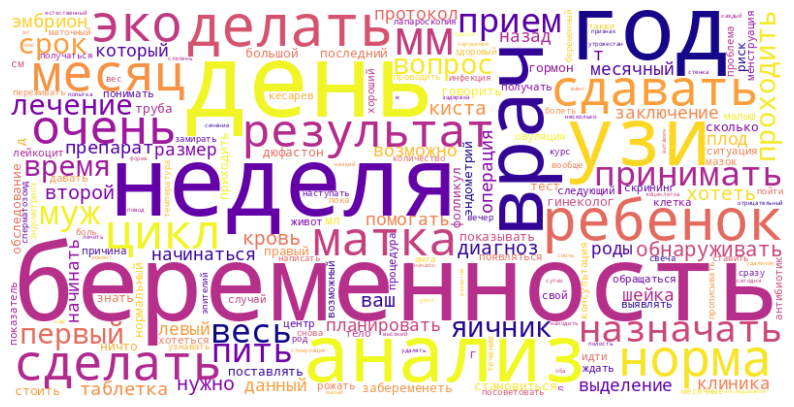

In [ ]:
wc_tokens = WordCloud(background_color='white', colormap = 'plasma', width=800, height=400, random_state=21, max_font_size=110).generate_from_frequencies(t_counts)
plt.figure(figsize=(10, 8))
plt.imshow(wc_tokens, interpolation="bilinear")
plt.axis("off")
plt.show

In [ ]:
print(len(text_bigrams))
Counter(text_bigrams).most_common(10)

73260


[(('беременность', 'неделя'), 133),
 (('неделя', 'беременность'), 125),
 (('день', 'цикл'), 116),
 (('шейка', 'матка'), 114),
 (('сдавать', 'анализ'), 106),
 (('срок', 'неделя'), 103),
 (('планировать', 'беременность'), 81),
 (('поставлять', 'диагноз'), 73),
 (('ваш', 'клиника'), 73),
 (('левый', 'яичник'), 69)]

In [ ]:
prepared_bigrams = ["_".join(gram) for gram in text_bigrams]
bigram_counts = Counter(prepared_bigrams)

<function matplotlib.pyplot.show(close=None, block=None)>

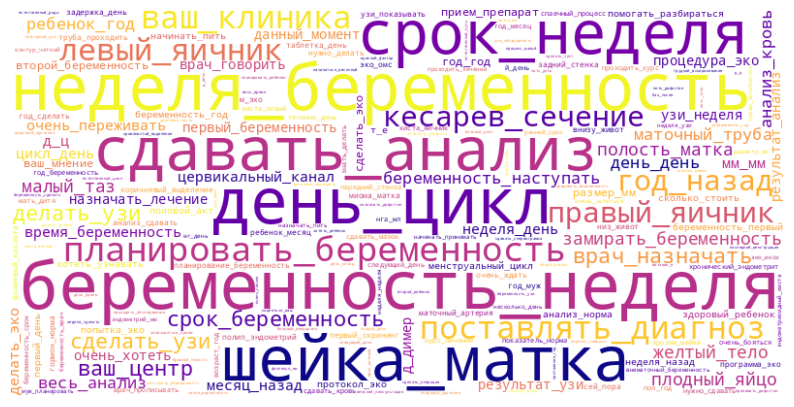

In [ ]:
wc_bigrams = WordCloud(background_color='white', colormap = 'plasma', width=800, height=400, random_state=21, max_font_size=110).generate_from_frequencies(bigram_counts)
plt.figure(figsize=(10, 8))
plt.imshow(wc_bigrams, interpolation="bilinear")
plt.axis("off")
plt.show

In [ ]:
print(len(text_tokens))
Counter(text_tokens).most_common(10)

74967


[('беременность', 1127),
 ('день', 1065),
 ('неделя', 916),
 ('год', 802),
 ('врач', 627),
 ('узи', 606),
 ('анализ', 598),
 ('ребенок', 572),
 ('делать', 572),
 ('норма', 463)]

In [ ]:
print(len(text_nouns))
Counter(text_nouns).most_common(10)

43689


[('беременность', 1127),
 ('день', 1065),
 ('неделя', 916),
 ('год', 802),
 ('врач', 627),
 ('узи', 606),
 ('анализ', 598),
 ('ребенок', 572),
 ('норма', 463),
 ('месяц', 459)]

In [ ]:
print(len(text_verbs))
Counter(text_verbs).most_common(10)

15488


[('делать', 572),
 ('сделать', 416),
 ('сдавать', 404),
 ('назначать', 350),
 ('принимать', 339),
 ('пить', 314),
 ('проходить', 290),
 ('обнаруживать', 278),
 ('хотеть', 252),
 ('планировать', 183)]

In [ ]:
v_counts = Counter(text_verbs)
s_counts = Counter(text_nouns)

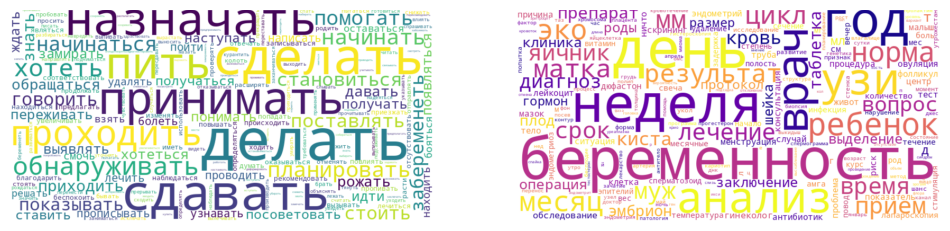

In [ ]:
# облака слов
v_wc = WordCloud(background_color='white', colormap = 'viridis', width=800, height=400, random_state=21, max_font_size=110).generate_from_frequencies(v_counts)
s_wc = WordCloud(background_color='white', colormap = 'plasma', width=800, height=400, random_state=21, max_font_size=110).generate_from_frequencies(s_counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 12))
ax1.imshow(v_wc, interpolation='bilinear')
ax1.axis('off')

ax2.imshow(s_wc, interpolation='bilinear')
ax2.axis('off')

plt.show()

In [ ]:
print(len(text_adjs))
Counter(text_adjs).most_common(10)

14827


[('очень', 380),
 ('весь', 321),
 ('первый', 312),
 ('ваш', 243),
 ('нужно', 234),
 ('второй', 231),
 ('месячный', 181),
 ('возможно', 168),
 ('который', 168),
 ('данный', 151)]

<function matplotlib.pyplot.show(close=None, block=None)>

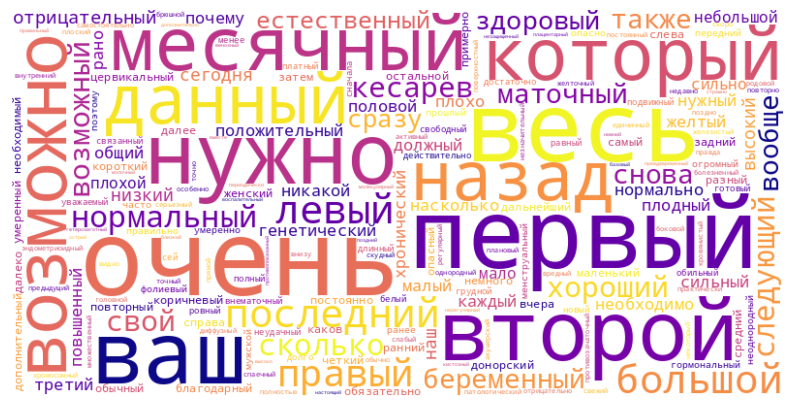

In [ ]:
a_counts = Counter(text_adjs)
a_wc = WordCloud(background_color='white', colormap = 'plasma', width=800, height=400, random_state=21, max_font_size=110).generate_from_frequencies(a_counts)
plt.figure(figsize=(10, 8))
plt.imshow(a_wc, interpolation="bilinear")
plt.axis("off")
plt.show

Таблица идёт в презентацию

In [ ]:
qa_df_short.loc[:, 'texts_lemmatized'] = text_lemmatized
qa_df_short = qa_df_short.drop(columns=['question_theme']).copy()
qa_df_short

,category,date,question_text,texts_lemmatized
0,Гинекология,20.12.2025,Как прервать беременность в домашних условиях ...,прерывать беременность домашний условие неделя
1,ЭКО,08.12.2025,Во многих клиниках обязательным требованием дл...,многий клиника обязательный требование становл...
2,ЭКО,05.12.2025,Если у девушки проблемы с зубами ( кариес ) Мо...,девушка проблема зуб кариес становиться донор ...
5,Гинекология,04.12.2025,Здравствуйте! Возможно пройти обследование дев...,возможно проходить обследование девочка год ис...
6,Беременность и роды,04.12.2025,Здравствуйте. У меня кровь 2- у мужа 1+. Перва...,кровь муж первый беременность г ребенок умират...
...,...,...,...,...
3993,Беременность и роды,23.10.2014,", Мне 26 лет, я пока только планирую беременно...",год пока планировать беременность смущать вопр...
4641,Педиатрия,23.10.2014,Здравствуйте! У моего малыша с рождения красны...,малыш рождение красный пятно носик бровь затыл...
4660,Педиатрия,23.10.2014,"У меня к вам несколько вопросов, ия буду ВАм о...",несколько вопрос ия очень признательный елси о...
4664,Педиатрия,23.10.2014,Мой ребенок постоянно тужится как это может вл...,ребенок постоянно тужиться влиять здоровье мес...


Частотники по категориям

In [ ]:
preg = qa_df_short.loc[qa_df_short['category']=='Беременность и роды', 'texts_lemmatized'].tolist()
preg_tokens = []
for text in preg:
  toks = text.split()
  preg_tokens.extend(toks)
print(len(preg_tokens))
print(preg_tokens[:10])

23706
['кровь', 'муж', 'первый', 'беременность', 'г', 'ребенок', 'умирать', 'центральный', 'предлежание', 'плацента']


In [ ]:
gin = qa_df_short.loc[qa_df_short['category']=='Гинекология', 'texts_lemmatized'].tolist()
gin_tokens = []
for text in gin:
  toks = text.split()
  gin_tokens.extend(toks)
print(len(gin_tokens))
print(gin_tokens[:10])

23746
['прерывать', 'беременность', 'домашний', 'условие', 'неделя', 'возможно', 'проходить', 'обследование', 'девочка', 'год']


In [ ]:
eco = qa_df_short.loc[qa_df_short['category']=='ЭКО', 'texts_lemmatized'].tolist()
eco_tokens = []
for text in eco:
  toks = text.split()
  eco_tokens.extend(toks)
print(len(eco_tokens))
print(eco_tokens[:10])

18611
['многий', 'клиника', 'обязательный', 'требование', 'становление', 'донор', 'яйцеклетка', 'являться', 'наличие', 'здоровый']


In [ ]:
ped = qa_df_short.loc[qa_df_short['category']=='Педиатрия', 'texts_lemmatized'].tolist()
ped_tokens = []
for text in ped:
  toks = text.split()
  ped_tokens.extend(toks)
print(len(ped_tokens))
print(ped_tokens[:10])

8904
['месяц', 'узи', 'головной', 'мозг', 'выставлять', 'заключение', 'эхо', 'картина', 'арахноидальный', 'киста']


In [ ]:
category_df = pd.DataFrame([Counter(preg_tokens).most_common(10), Counter(gin_tokens).most_common(10), Counter(eco_tokens).most_common(10), Counter(ped_tokens).most_common(10)]).T.rename(columns={0: 'Беременность и роды', 1: 'Гинекология', 2: 'ЭКО', 3: 'Педиатрия'})
category_df

,Беременность и роды,Гинекология,ЭКО,Педиатрия
0,"(беременность, 703)","(день, 405)","(эко, 394)","(ребенок, 205)"
1,"(неделя, 647)","(год, 305)","(год, 291)","(месяц, 127)"
2,"(день, 335)","(беременность, 257)","(день, 206)","(день, 119)"
3,"(узи, 270)","(врач, 229)","(анализ, 171)","(норма, 78)"
4,"(срок, 243)","(матка, 219)","(эмбрион, 164)","(анализ, 77)"
5,"(ребенок, 229)","(узи, 208)","(беременность, 158)","(делать, 75)"
6,"(врач, 227)","(цикл, 197)","(муж, 153)","(год, 66)"
7,"(мм, 174)","(месяц, 193)","(делать, 153)","(неделя, 53)"
8,"(анализ, 170)","(делать, 184)","(протокол, 151)","(врач, 50)"
9,"(делать, 160)","(анализ, 180)","(цикл, 122)","(температура, 49)"


In [ ]:
ped = qa_df_short.loc[qa_df_short['category']=='Педиатрия', 'texts_lemmatized'].tolist()
ped_tokens = []
for text in ped:
  toks = text.split()
  ped_tokens.extend(toks)
print(len(ped_tokens))
print(ped_tokens[:10])

8904
['месяц', 'узи', 'головной', 'мозг', 'выставлять', 'заключение', 'эхо', 'картина', 'арахноидальный', 'киста']


In [ ]:
Counter(ped_tokens).most_common(10)

[('ребенок', 205),
 ('месяц', 127),
 ('день', 119),
 ('норма', 78),
 ('анализ', 77),
 ('делать', 75),
 ('год', 66),
 ('неделя', 53),
 ('врач', 50),
 ('температура', 49)]

In [ ]:
from nltk import bigrams

In [ ]:
ped_bigrams = list(bigrams(ped_tokens))

In [ ]:
ped_bigrams[:10]

[('месяц', 'узи'),
 ('узи', 'головной'),
 ('головной', 'мозг'),
 ('мозг', 'выставлять'),
 ('выставлять', 'заключение'),
 ('заключение', 'эхо'),
 ('эхо', 'картина'),
 ('картина', 'арахноидальный'),
 ('арахноидальный', 'киста'),
 ('киста', 'промежуточный')]

In [ ]:
Counter(ped_bigrams).most_common(10)

[(('ребенок', 'год'), 25),
 (('ребенок', 'месяц'), 22),
 (('анализ', 'кровь'), 18),
 (('сдавать', 'анализ'), 18),
 (('анализ', 'кал'), 11),
 (('поставлять', 'диагноз'), 11),
 (('сын', 'год'), 10),
 (('общий', 'анализ'), 10),
 (('год', 'месяц'), 10),
 (('ребенок', 'мес'), 10)]

In [ ]:
prepared_ped_bigrams = ["_".join(gram) for gram in ped_bigrams]

In [ ]:
prepared_ped_bigrams[:5]

['месяц_узи',
 'узи_головной',
 'головной_мозг',
 'мозг_выставлять',
 'выставлять_заключение']

In [ ]:
ped_counts = Counter(ped_tokens)
ped_bigram_counts = Counter(prepared_ped_bigrams)

In [ ]:
ped_df = pd.DataFrame([Counter(ped_tokens)]).T
ped_df.to_excel("ped_df.xlsx")

In [ ]:
ped_bigram_df = pd.DataFrame([Counter(prepared_ped_bigrams)]).T
ped_bigram_df.to_excel("ped_bigram_df.xlsx")

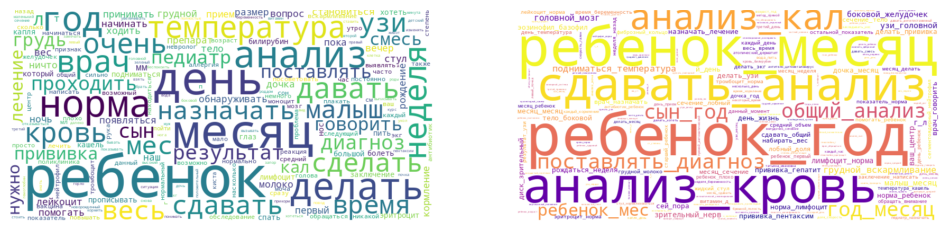

In [ ]:
# облака слов
wc1 = WordCloud(background_color='white', colormap = 'viridis', width=800, height=400, random_state=21, max_font_size=110).generate_from_frequencies(ped_counts)
wc2 = WordCloud(background_color='white', colormap = 'plasma', width=800, height=400, random_state=21, max_font_size=110).generate_from_frequencies(ped_bigram_counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 12))
ax1.imshow(wc1, interpolation='bilinear')
ax1.axis('off')

ax2.imshow(wc2, interpolation='bilinear')
ax2.axis('off')

plt.show()

Визуализация данных TSNE tf-idf на униграммы

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tfidf_vec = TfidfVectorizer(max_features=4000)
transformed_text = tfidf_vec.fit_transform(text_lemmatized)

In [ ]:
fn = tfidf_vec.get_feature_names_out()
print(fn.shape)

(4000,)


In [ ]:
%%time
X_embedded = TSNE(n_components=2, init='random', perplexity=50).fit_transform(transformed_text.toarray())

CPU times: user 31.6 s, sys: 113 ms, total: 31.8 s
Wall time: 42.1 s


In [ ]:
colors = qa_df_short['category'].astype('category').cat.codes

In [ ]:
categories_list = qa_df_short['category'].astype('category').cat.categories
for code, name in enumerate(categories_list):
  print(f"{code}: {name}")

0: Беременность и роды
1: Гинекология
2: Педиатрия
3: ЭКО


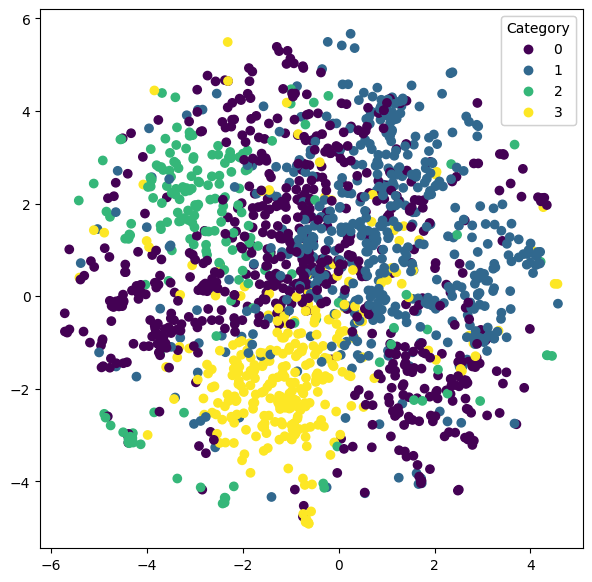

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))
scatter = plt.scatter(X_embedded[:,0], X_embedded[:,1], c=colors)
# Generate a legend from the scatter object
legend = ax.legend(*scatter.legend_elements(), loc="upper right", title="Category")
ax.add_artist(legend)
plt.show()

TSNE tf-idf униграммы и биграммы

In [ ]:
tfidf_vec_2 = TfidfVectorizer(ngram_range=(1, 2), max_df = 0.8, min_df = 3, max_features=4000)
transformed_text_2 = tfidf_vec_2.fit_transform(text_lemmatized)

In [ ]:
fn2 = tfidf_vec_2.get_feature_names_out()
print(fn2.shape)

(4000,)


In [ ]:
%%time
X_embedded_2 = TSNE(n_components=2, init='random', perplexity=50).fit_transform(transformed_text_2.toarray())

CPU times: user 27.1 s, sys: 103 ms, total: 27.2 s
Wall time: 43.2 s


In [ ]:
colors = qa_df_short['category'].astype('category').cat.codes

In [ ]:
categories_list = qa_df_short['category'].astype('category').cat.categories
for code, name in enumerate(categories_list):
  print(f"{code}: {name}")

0: Беременность и роды
1: Гинекология
2: Педиатрия
3: ЭКО


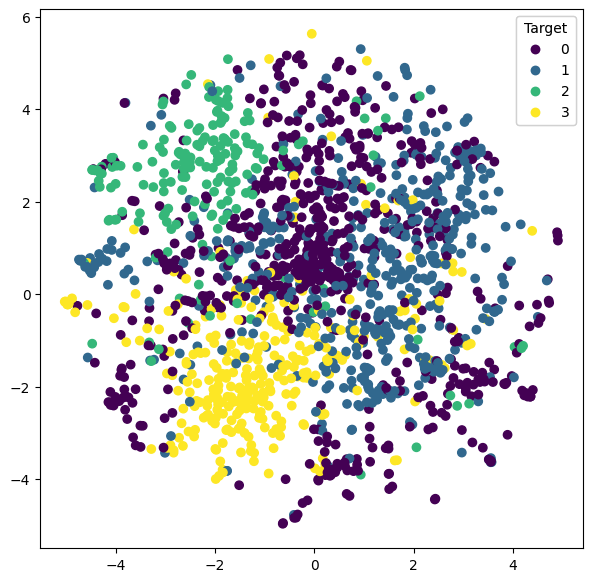

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))
scatter = plt.scatter(X_embedded_2[:,0], X_embedded_2[:,1], c=colors)
# Generate a legend from the scatter object
legend = ax.legend(*scatter.legend_elements(), loc="upper right", title="Target")
ax.add_artist(legend)
plt.show()

Подготовка данных для подачи в модель. Делим датасет на трейн и тест.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# по умолчанию test_size=0.25
X_train, X_test, y_train, y_test = train_test_split(qa_df_short['texts_lemmatized'],
                                                    qa_df_short['category'].tolist(),
                                                    stratify=qa_df_short['category'],
                                                    random_state=42)

TF-IDF на токены

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(max_df=0.8, min_df=3)

In [ ]:
tfidf.fit(X_train)

TfidfVectorizer(max_df=0.8, min_df=3)

In [ ]:
X_train_vec = tfidf.transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [ ]:
feature_names = tfidf.get_feature_names_out()
print(feature_names.shape)
feature_names

(2431,)


array(['аборт', 'абсолютно', 'август', ..., 'ярин', 'ярина', 'яркий'],
      dtype=object)

Кодируем категории

In [ ]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

LOGREG на tf-idf

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.metrics import classification_report, r2_score, mean_absolute_error, mean_squared_error

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc

In [ ]:
logreg = LogisticRegression(random_state=42, multi_class='ovr', class_weight='balanced')

In [ ]:
logreg.fit(X_train_vec, y_train_enc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', multi_class='ovr', random_state=42)

In [ ]:
class_pred = logreg.predict(X_test_vec)

In [ ]:
print("LogisticRegression + TF-IDF на униграммы")
print('__________________')
print(classification_report(y_test_enc,
                            class_pred,
                            target_names=le.classes_))

LogisticRegression + TF-IDF на униграммы
__________________
                     precision    recall  f1-score   support

Беременность и роды       0.84      0.84      0.84       169
        Гинекология       0.78      0.78      0.78       131
          Педиатрия       0.90      0.91      0.91        47
                ЭКО       0.87      0.86      0.87        80

           accuracy                           0.83       427
          macro avg       0.85      0.85      0.85       427
       weighted avg       0.83      0.83      0.83       427



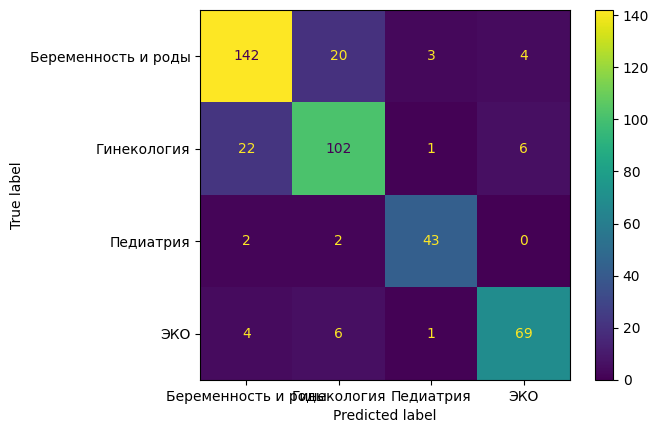

In [ ]:
cm = confusion_matrix(y_test_enc, class_pred)
cm_display = ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

In [ ]:
features_df = pd.DataFrame()
features_df['term'] = feature_names

for i in range(len(le.classes_)):
    name = le.classes_[i]
    features_df[name] = logreg.coef_[i]

In [ ]:
features_df.sort_values(by='Беременность и роды', ascending=False).reset_index(drop=True)[:10]

,term,Беременность и роды,Гинекология,Педиатрия,ЭКО
0,беременность,4.970186,-1.983919,-3.824124,-1.928642
1,неделя,4.206445,-2.019515,-1.991177,-2.846927
2,срок,2.567648,-1.653968,-1.665016,-0.971641
3,беременный,2.326766,-1.052807,-1.075563,-1.006083
4,роды,2.075836,-1.098911,-0.542598,-1.131410
5,плод,1.983372,-1.456995,-0.597558,-0.526051
6,кесарев,1.714563,-0.620140,-1.057339,-0.776807
7,переживать,1.358035,-0.978798,-0.587350,-0.239634
8,род,1.338137,-0.861033,-0.458265,-0.545786
9,риск,1.213048,-1.069393,-0.535321,0.162075


In [ ]:
features_df.sort_values(by='Гинекология', ascending=False).reset_index(drop=True)[:10]

,term,Беременность и роды,Гинекология,Педиатрия,ЭКО
0,матка,-1.020994,2.526019,-1.624484,-0.978783
1,лечение,-1.024473,2.281439,-0.991917,-0.754862
2,месячный,-1.079274,1.834847,-0.946431,-0.374743
3,выделение,-0.851124,1.776871,-1.081426,-0.340781
4,прием,-0.484659,1.737240,-1.251749,-0.717258
5,менструация,-0.734070,1.684078,-0.854918,-0.794119
6,полип,-0.827789,1.553386,-0.539168,-0.498065
7,яичник,-1.315792,1.456012,-1.232216,0.336609
8,свеча,-0.626948,1.440410,-0.615390,-0.681342
9,дюфастон,-0.557648,1.435245,-0.767593,-0.682699


In [ ]:
features_df.sort_values(by='Педиатрия', ascending=False).reset_index(drop=True)[:10]

,term,Беременность и роды,Гинекология,Педиатрия,ЭКО
0,ребенок,0.198245,-2.965777,5.081566,-1.045508
1,месяц,-1.867260,0.095628,3.130230,-0.812677
2,сын,-0.808498,-0.734474,2.717004,-0.509312
3,прививка,-0.761139,-0.875096,2.552004,-0.591523
4,малыш,0.493723,-1.292725,2.277577,-1.048329
5,дочка,-0.808325,-0.403647,2.222882,-0.209185
6,новорожденный,-0.406004,-0.475414,1.787608,-0.289987
7,педиатр,-0.591425,-0.464069,1.787546,-0.228663
8,экг,-0.504227,-0.349101,1.534827,-0.293093
9,мес,-0.528787,-0.476857,1.500340,-0.157600


In [ ]:
features_df.sort_values(by='ЭКО', ascending=False).reset_index(drop=True)[:10]

,term,Беременность и роды,Гинекология,Педиатрия,ЭКО
0,эко,-3.119458,-3.426788,-2.211808,7.735471
1,протокол,-1.400548,-1.626392,-0.780872,3.213299
2,эмбрион,-1.600171,-0.937059,-1.094729,3.085601
3,перенос,-1.127080,-0.796886,-0.567412,2.823691
4,муж,0.331536,-1.136618,-1.609420,2.395460
5,амга,-0.975976,-0.752237,-0.555005,2.380698
6,сперматозоид,-0.846712,-0.739987,-0.527851,2.030217
7,омс,-0.834878,-0.918265,-0.505302,1.987941
8,спермограмма,-0.312837,-0.852052,-0.559482,1.823373
9,клиника,-0.845903,-0.759999,-0.609926,1.816467


TF-IDF на униграммы и биграммы

In [ ]:
tfidf_2 = TfidfVectorizer(ngram_range=(1, 2), max_df = 0.8, min_df = 3)

In [ ]:
tfidf_2.fit(X_train)

TfidfVectorizer(max_df=0.8, min_df=3, ngram_range=(1, 2))

In [ ]:
X_train_vec_2 = tfidf_2.transform(X_train)
X_test_vec_2 = tfidf_2.transform(X_test)

In [ ]:
feature_names_2 = tfidf_2.get_feature_names_out()
print(feature_names_2.shape)
feature_names_2

(4502,)


array(['аборт', 'абсолютно', 'август', ..., 'ярин течение', 'ярина',
       'яркий'], dtype=object)

LOGREG tf-idf на биграммы

In [ ]:
logreg_2 = LogisticRegression(random_state=42, multi_class='ovr', class_weight='balanced')

In [ ]:
logreg_2.fit(X_train_vec_2, y_train_enc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', multi_class='ovr', random_state=42)

In [ ]:
class_pred_2 = logreg_2.predict(X_test_vec_2)

In [ ]:
print("LogisticRegression + TF-IDF на униграммы и биграммы")
print('__________________')
print(classification_report(y_test_enc,
                            class_pred_2,
                            target_names=le.classes_))

LogisticRegression + TF-IDF на униграммы и биграммы
__________________
                     precision    recall  f1-score   support

Беременность и роды       0.84      0.85      0.84       169
        Гинекология       0.80      0.79      0.79       131
          Педиатрия       0.88      0.91      0.90        47
                ЭКО       0.89      0.88      0.88        80

           accuracy                           0.84       427
          macro avg       0.85      0.86      0.85       427
       weighted avg       0.84      0.84      0.84       427



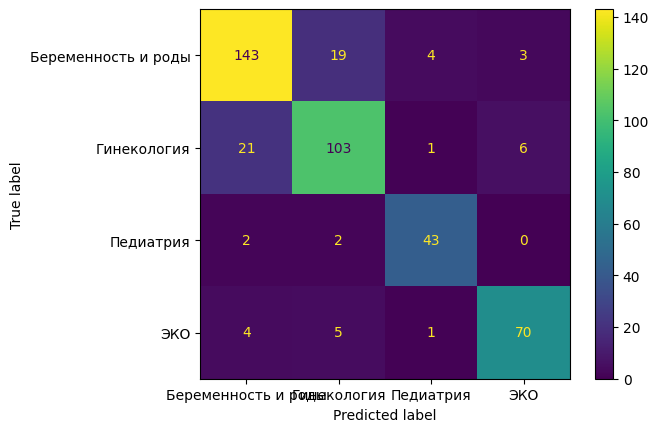

In [ ]:
cm = confusion_matrix(y_test_enc, class_pred_2)
cm_display = ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

In [ ]:
features_df_2 = pd.DataFrame()
features_df_2['term'] = feature_names_2

for i in range(len(le.classes_)):
    name = le.classes_[i]
    features_df_2[name] = logreg_2.coef_[i]

In [ ]:
features_df_2.sort_values(by='Беременность и роды', ascending=False).reset_index(drop=True)[:10]

,term,Беременность и роды,Гинекология,Педиатрия,ЭКО
0,беременность,4.587302,-1.835127,-3.437368,-1.721739
1,неделя,3.979416,-1.894544,-1.694644,-2.656545
2,срок,2.377953,-1.467199,-1.486340,-0.901730
3,беременный,2.229662,-0.957430,-0.961694,-0.977550
4,роды,1.968640,-1.055899,-0.408916,-1.076361
5,беременность неделя,1.957719,-1.132596,-1.048254,-0.862151
6,плод,1.879084,-1.349964,-0.500210,-0.518014
7,кесарев,1.528222,-0.557118,-0.871531,-0.729169
8,неделя беременность,1.359563,-0.627289,-0.615628,-0.834093
9,род,1.320102,-0.841634,-0.418898,-0.527371



KNN CLASSIFIER tf-idf на униграммы

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

In [ ]:
# подбираем гиперпараметр "количество соседей"
param_grid = {'n_neighbors': np.arange(1, 50)}
random_search = RandomizedSearchCV(KNeighborsClassifier(metric='cosine'), param_grid, cv=5, scoring = 'f1_weighted')
random_search.fit(X_train_vec, y_train_enc)

print(f"Лучшее k: {random_search.best_params_['n_neighbors']}")

Лучшее k: 17


In [ ]:
knn = KNeighborsClassifier(n_neighbors=17, metric='cosine')

In [ ]:
knn.fit(X_train_vec, y_train_enc)

KNeighborsClassifier(metric='cosine', n_neighbors=17)

In [ ]:
knn_pred = knn.predict(X_test_vec)

In [ ]:
print("KNN + TF-IDF на униграммы")
print('__________________')
print(classification_report(y_test_enc, knn_pred, target_names=le.classes_))

KNN + TF-IDF на униграммы
__________________
                     precision    recall  f1-score   support

Беременность и роды       0.71      0.88      0.79       169
        Гинекология       0.78      0.71      0.74       131
          Педиатрия       0.93      0.53      0.68        47
                ЭКО       0.86      0.79      0.82        80

           accuracy                           0.77       427
          macro avg       0.82      0.73      0.76       427
       weighted avg       0.78      0.77      0.77       427



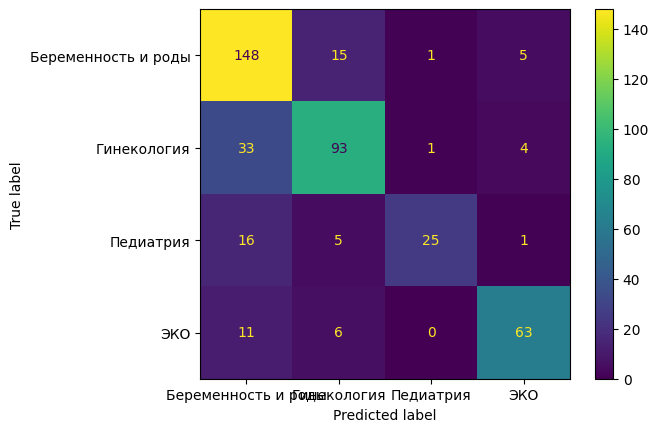

In [ ]:
cm = confusion_matrix(y_test_enc, knn_pred)
cm_display = ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

KNN CLASSIFIER tf-idf на униграммы и биграммы

In [ ]:
# подбираем гиперпараметр "количество соседей"
param_grid = {'n_neighbors': np.arange(1, 50)}
random_search = RandomizedSearchCV(KNeighborsClassifier(metric='cosine'), param_grid, cv=5, scoring = 'f1_weighted')
random_search.fit(X_train_vec_2, y_train_enc)

print(f"Лучшее k: {random_search.best_params_['n_neighbors']}")

Лучшее k: 24


In [ ]:
knn_2 = KNeighborsClassifier(n_neighbors=24, metric='cosine')

In [ ]:
knn_2.fit(X_train_vec_2, y_train_enc)

KNeighborsClassifier(metric='cosine', n_neighbors=24)

In [ ]:
knn_pred_2 = knn_2.predict(X_test_vec_2)

In [ ]:
print("KNN + TF-IDF на униграммы и биграммы")
print('__________________')
print(classification_report(y_test_enc, knn_pred_2, target_names=le.classes_))

KNN + TF-IDF на униграммы и биграммы
__________________
                     precision    recall  f1-score   support

Беременность и роды       0.73      0.85      0.78       169
        Гинекология       0.76      0.73      0.74       131
          Педиатрия       0.97      0.66      0.78        47
                ЭКО       0.88      0.81      0.84        80

           accuracy                           0.78       427
          macro avg       0.83      0.76      0.79       427
       weighted avg       0.79      0.78      0.78       427



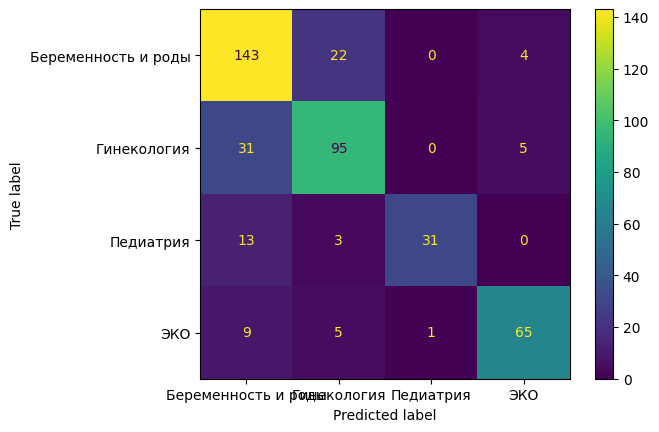

In [ ]:
cm = confusion_matrix(y_test_enc, knn_pred_2)
cm_display = ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring = 'f1_weighted', n_jobs=-1)
grid_search.fit(X_train_vec, y_train_enc)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший результат F1: {grid_search.best_score_}")

Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
Лучший результат F1: 0.7936900539613937


In [ ]:
ranfor = RandomForestClassifier(max_depth=None, max_features='sqrt', min_samples_split=10, n_estimators=300, class_weight='balanced', random_state=42)

In [ ]:
ranfor_preds = ranfor.predict(X_test_vec)

In [ ]:
print("RandomForest + TF-IDF на униграммы")
print('__________________')
print(classification_report(y_test_enc, ranfor_preds, target_names=le.classes_))

RandomForest + TF-IDF на униграммы
__________________
                     precision    recall  f1-score   support

Беременность и роды       0.81      0.88      0.84       169
        Гинекология       0.83      0.71      0.77       131
          Педиатрия       0.88      0.91      0.90        47
                ЭКО       0.85      0.89      0.87        80

           accuracy                           0.83       427
          macro avg       0.84      0.85      0.84       427
       weighted avg       0.83      0.83      0.83       427



In [ ]:
ranfor.fit(X_train_vec, y_train_enc)

RandomForestClassifier(class_weight='balanced', min_samples_split=10,
                       n_estimators=300, random_state=42)

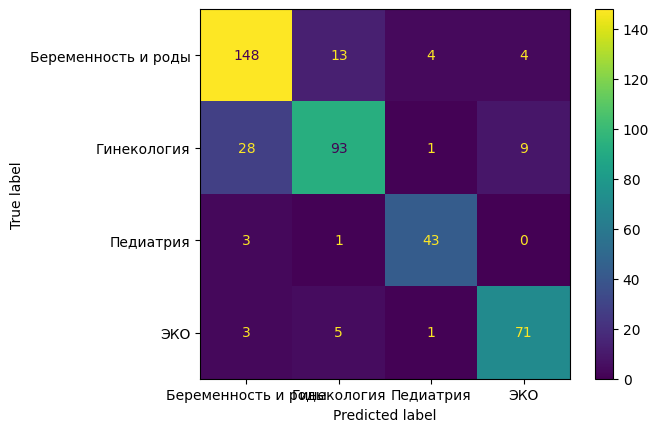

In [ ]:
cm = confusion_matrix(y_test_enc, ranfor_preds)
cm_display = ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

Random Forest tf-idf на униграммах и биграммах

In [ ]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring = 'f1_weighted', n_jobs=-1)
grid_search.fit(X_train_vec_2, y_train_enc)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший результат F1: {grid_search.best_score_}")

Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
Лучший результат F1: 0.7822042876873619


In [ ]:
ranfor_2 = RandomForestClassifier(max_depth=None, max_features='sqrt', min_samples_split=10, n_estimators=300, class_weight='balanced', random_state=42)

In [ ]:
ranfor_2.fit(X_train_vec_2, y_train_enc)

RandomForestClassifier(class_weight='balanced', min_samples_split=10,
                       n_estimators=300, random_state=42)

In [ ]:
ranfor_preds_2 = ranfor_2.predict(X_test_vec_2)

In [ ]:
print("RandomForest + TF-IDF на униграммы и биграммы")
print('__________________')
print(classification_report(y_test_enc, ranfor_preds_2, target_names=le.classes_))

RandomForest + TF-IDF на униграммы и биграммы
__________________
                     precision    recall  f1-score   support

Беременность и роды       0.81      0.87      0.84       169
        Гинекология       0.82      0.70      0.76       131
          Педиатрия       0.90      0.91      0.91        47
                ЭКО       0.83      0.89      0.86        80

           accuracy                           0.83       427
          macro avg       0.84      0.84      0.84       427
       weighted avg       0.83      0.83      0.82       427



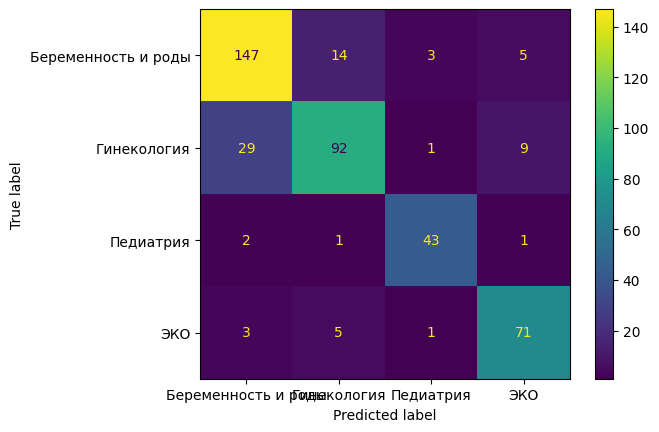

In [ ]:
cm = confusion_matrix(y_test_enc, ranfor_preds_2)
cm_display = ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

Пробую CatBoost (с помощью google ai mode)

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier, Pool

In [ ]:
# таблица - check, для удобства
qa_df_short

,category,date,question_text,texts_lemmatized
0,Гинекология,20.12.2025,Как прервать беременность в домашних условиях ...,прерывать беременность домашний условие неделя
1,ЭКО,08.12.2025,Во многих клиниках обязательным требованием дл...,многий клиника обязательный требование становл...
2,ЭКО,05.12.2025,Если у девушки проблемы с зубами ( кариес ) Мо...,девушка проблема зуб кариес становиться донор ...
5,Гинекология,04.12.2025,Здравствуйте! Возможно пройти обследование дев...,возможно проходить обследование девочка год ис...
6,Беременность и роды,04.12.2025,Здравствуйте. У меня кровь 2- у мужа 1+. Перва...,кровь муж первый беременность г ребенок умират...
...,...,...,...,...
3993,Беременность и роды,23.10.2014,", Мне 26 лет, я пока только планирую беременно...",год пока планировать беременность смущать вопр...
4641,Педиатрия,23.10.2014,Здравствуйте! У моего малыша с рождения красны...,малыш рождение красный пятно носик бровь затыл...
4660,Педиатрия,23.10.2014,"У меня к вам несколько вопросов, ия буду ВАм о...",несколько вопрос ия очень признательный елси о...
4664,Педиатрия,23.10.2014,Мой ребенок постоянно тужится как это может вл...,ребенок постоянно тужиться влиять здоровье мес...


In [ ]:
# сразу на два текста - сырой и лемматизированный
X = qa_df_short[['question_text', 'texts_lemmatized']]
y = qa_df_short['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Определение текстовых признаков
text_features = ['question_text', 'texts_lemmatized']

# Инициализация и обучение модели
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    text_features=text_features,
    task_type="CPU",
    verbose=100,
    devices='0'
)

model.fit(
    X_train, y_train,
    text_features=text_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

# Проверка результата
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

0:	learn: 1.2901087	test: 1.2962455	best: 1.2962455 (0)	total: 14.4s	remaining: 4h 1s
100:	learn: 0.4382293	test: 0.6014519	best: 0.6012492 (85)	total: 4m 56s	remaining: 44m 1s
200:	learn: 0.3466661	test: 0.6016836	best: 0.5968958 (181)	total: 8m 27s	remaining: 33m 37s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5968958441
bestIteration = 181

Shrink model to first 182 iterations.
                     precision    recall  f1-score   support

Беременность и роды       0.86      0.83      0.84       169
        Гинекология       0.73      0.77      0.75       128
          Педиатрия       0.84      0.76      0.80        49
                ЭКО       0.80      0.84      0.82        81

           accuracy                           0.81       427
          macro avg       0.81      0.80      0.80       427
       weighted avg       0.81      0.81      0.81       427



         Feature Id  Importances
0  texts_lemmatized    79.913291
1     question_text    20.086709


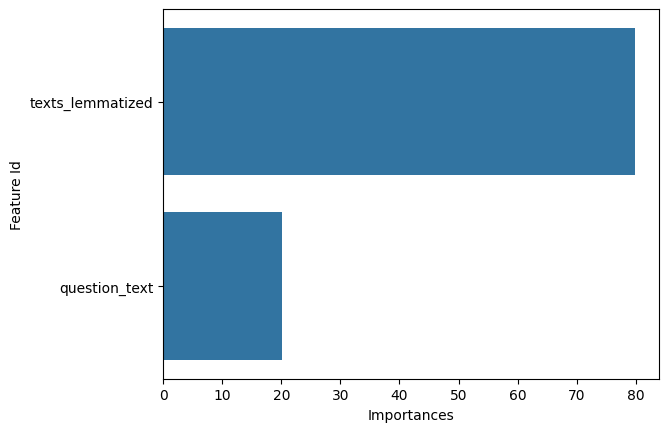

In [ ]:
import matplotlib.pyplot as plt

feat_imp = model.get_feature_importance(prettified=True)
print(feat_imp)

# Визуализация
import seaborn as sns
sns.barplot(x="Importances", y="Feature Id", data=feat_imp)
plt.show()

Пробую CatBoost на биграммах (с помощью google ai mode)

In [ ]:
X = qa_df_short[['question_text', 'texts_lemmatized']]
y = qa_df_short['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Определение текстовых признаков
text_features = ['question_text', 'texts_lemmatized']

# Инициализация и обучение модели
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    tokenizers=[{
        'tokenizer_id': 'Space',
        'separator_type': 'ByDelimiter',
        'delimiter': ' '
    }],
    dictionaries=[
        {
            'dictionary_id': 'WordAndBiGram',
            'gram_order': '1',       # Сначала берем одиночные слова
            'max_dictionary_size': '50000'
        },
        {
            'dictionary_id': 'BiGramOnly',
            'gram_order': '2',       # И отдельно пары слов
            'max_dictionary_size': '50000'
        }
    ],
    feature_calcers=[
        'BoW:top_tokens_count=10000:dictionaries=WordAndBiGram',
        'NaiveBayes:dictionaries=WordAndBiGram'
    ],
    text_features=text_features,
    task_type="CPU",
    verbose=100,
    devices='0'
)

model.fit(
    X_train, y_train,
    text_features=text_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

# Проверка результата
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

0:	learn: 1.2745523	test: 1.2848761	best: 1.2848761 (0)	total: 5.59s	remaining: 1h 33m 8s
100:	learn: 0.4547079	test: 0.5831627	best: 0.5831627 (100)	total: 6m 19s	remaining: 56m 17s
200:	learn: 0.3606898	test: 0.5802717	best: 0.5787471 (191)	total: 12m 17s	remaining: 48m 53s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.57846128
bestIteration = 205

Shrink model to first 206 iterations.
                     precision    recall  f1-score   support

Беременность и роды       0.87      0.85      0.86       169
        Гинекология       0.76      0.79      0.77       128
          Педиатрия       0.88      0.78      0.83        49
                ЭКО       0.80      0.85      0.83        81

           accuracy                           0.82       427
          macro avg       0.83      0.82      0.82       427
       weighted avg       0.82      0.82      0.82       427



 GradlientBoosting tf-idf на униграммы

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gradboo = GradientBoostingClassifier(random_state=42)
gradboo.fit(X_train_vec, y_train_enc)

GradientBoostingClassifier(random_state=42)

In [ ]:
gradboo_preds = gradboo.predict(X_test_vec)

In [ ]:
print("GradientBoosting + TF-IDF на униграммы")
print('__________________')
print(classification_report(y_test_enc, gradboo_preds, target_names=le.classes_))

GradientBoosting + TF-IDF на униграммы
__________________
                     precision    recall  f1-score   support

Беременность и роды       0.82      0.86      0.84       169
        Гинекология       0.79      0.73      0.76       131
          Педиатрия       0.86      0.79      0.82        47
                ЭКО       0.86      0.91      0.88        80

           accuracy                           0.82       427
          macro avg       0.83      0.82      0.83       427
       weighted avg       0.82      0.82      0.82       427



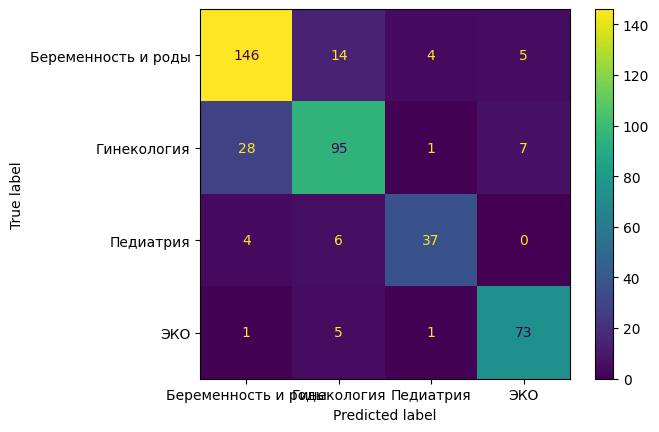

In [ ]:
cm = confusion_matrix(y_test_enc, gradboo_preds)
cm_display = ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

GradlientBoosting tf-idf на униграммы и биграммы

In [ ]:
gradboo_2 = GradientBoostingClassifier(random_state=42)
gradboo_2.fit(X_train_vec_2, y_train_enc)

GradientBoostingClassifier(random_state=42)

In [ ]:
gradboo_preds_2 = gradboo_2.predict(X_test_vec_2)

In [ ]:
print("GradientBoosting + TF-IDF на униграммы и биграммы")
print('__________________')
print(classification_report(y_test_enc, gradboo_preds_2, target_names=le.classes_))

GradientBoosting + TF-IDF на униграммы и биграммы
__________________
                     precision    recall  f1-score   support

Беременность и роды       0.80      0.86      0.83       169
        Гинекология       0.77      0.71      0.74       131
          Педиатрия       0.86      0.77      0.81        47
                ЭКО       0.88      0.90      0.89        80

           accuracy                           0.81       427
          macro avg       0.83      0.81      0.82       427
       weighted avg       0.81      0.81      0.81       427



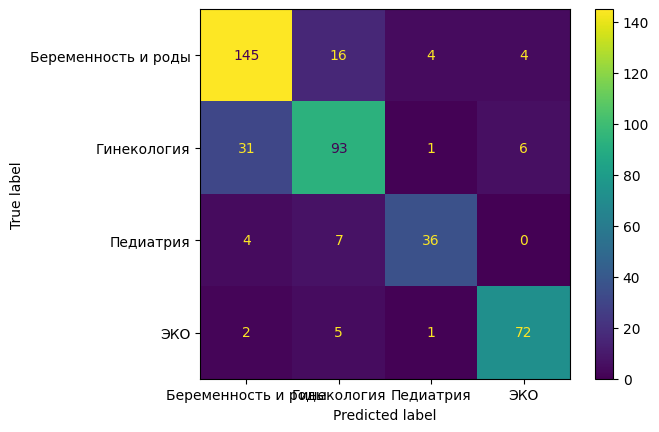

In [ ]:
cm = confusion_matrix(y_test_enc, gradboo_preds_2)
cm_display = ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

Multinomial NB - не лучший выбор, т.к. нет встроенного параметра class_weight

Поэтому ComplementNB tf-idf на униграммы

In [ ]:
from sklearn.naive_bayes import ComplementNB

In [ ]:
сnb = ComplementNB()
сnb.fit(X_train_vec, y_train_enc)
сnb_pred = сnb.predict(X_test_vec)

In [ ]:
print("ComplementNB + TF-IDF на униграммы")
print('__________________')
print(classification_report(y_test_enc, сnb_pred, target_names=le.classes_))

ComplementNB + TF-IDF на униграммы
__________________
                     precision    recall  f1-score   support

Беременность и роды       0.83      0.82      0.82       169
        Гинекология       0.78      0.79      0.79       131
          Педиатрия       0.82      0.70      0.76        47
                ЭКО       0.86      0.94      0.90        80

           accuracy                           0.82       427
          macro avg       0.82      0.81      0.82       427
       weighted avg       0.82      0.82      0.82       427



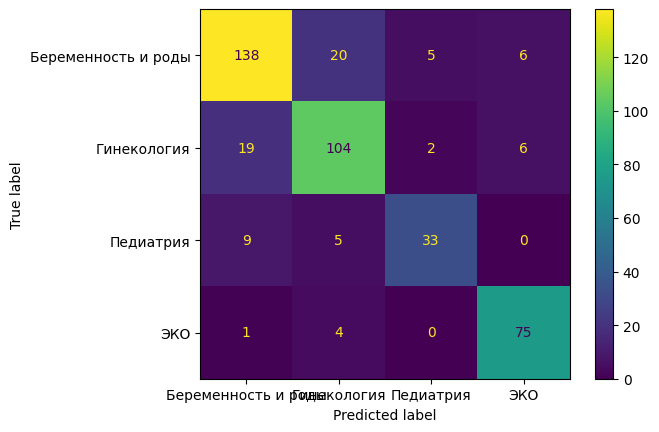

In [ ]:
cm = confusion_matrix(y_test_enc, сnb_pred)
cm_display = ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

ComplementNB tf-idf на униграммы и биграммы


In [ ]:
cnb_2 = ComplementNB()
cnb_2.fit(X_train_vec_2, y_train_enc)
cnb_pred_2 = cnb_2.predict(X_test_vec_2)

In [ ]:
print("ComplementNB + TF-IDF на униграммы и биграммы")
print('__________________')
print(classification_report(y_test_enc, cnb_pred_2, target_names=le.classes_))

ComplementNB + TF-IDF на униграммы и биграммы
__________________
                     precision    recall  f1-score   support

Беременность и роды       0.83      0.85      0.84       169
        Гинекология       0.82      0.79      0.80       131
          Педиатрия       0.87      0.85      0.86        47
                ЭКО       0.89      0.93      0.91        80

           accuracy                           0.85       427
          macro avg       0.85      0.85      0.85       427
       weighted avg       0.84      0.85      0.84       427



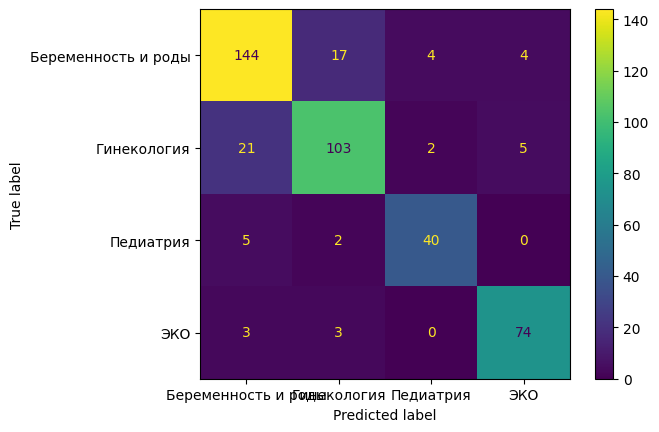

In [ ]:
cm = confusion_matrix(y_test_enc, cnb_pred_2)
cm_display = ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()